Slope (m): 0.10976773783009863
Intercept (c): 98.24832962138083
Predicted Price for 2000 sqft: 317.7838052815781


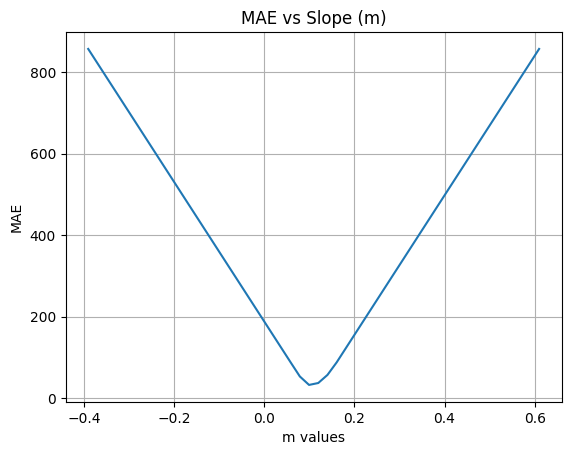

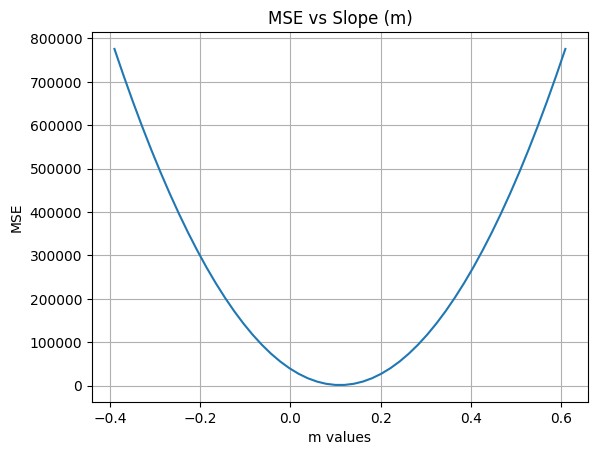

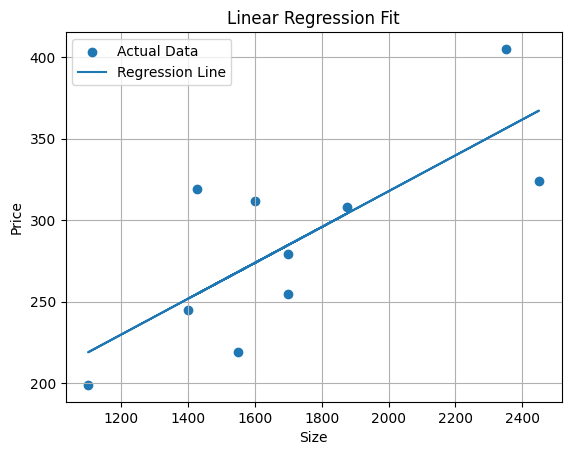

R2 Score: 0.5808173118722723
Best Polynomial Coefficients: [-2.79437846e-02  1.44248650e+00 -2.41395495e-01  3.91431971e-05]


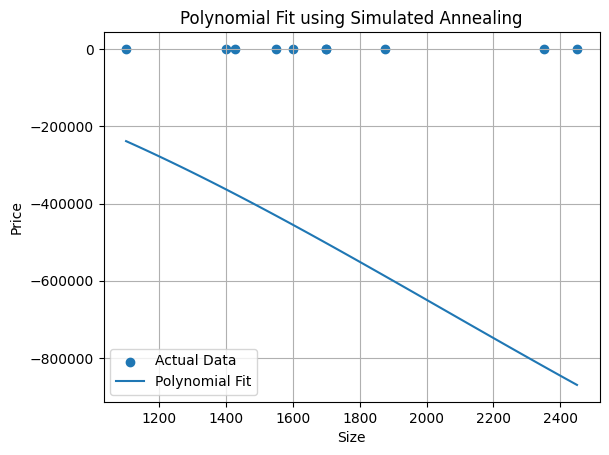

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

size = np.array([1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700])
price = np.array([245, 312, 279, 308, 199, 219, 405, 324, 319, 255])

m = np.sum((size - np.mean(size)) * (price - np.mean(price))) / np.sum((size - np.mean(size))**2)
c = np.mean(price) - m * np.mean(size)

print("Slope (m):", m)
print("Intercept (c):", c)

y_pred = m * size + c

print("Predicted Price for 2000 sqft:", m*2000 + c)

m_vals = np.linspace(m-0.5, m+0.5, 50)
mae_values = []

for m_temp in m_vals:
    y_temp = m_temp * size + c
    mae_values.append(mean_absolute_error(price, y_temp))

plt.figure()
plt.plot(m_vals, mae_values)
plt.title("MAE vs Slope (m)")
plt.xlabel("m values")
plt.ylabel("MAE")
plt.grid()
plt.show()

mse_values = []

for m_temp in m_vals:
    y_temp = m_temp * size + c
    mse_values.append(mean_squared_error(price, y_temp))

plt.figure()
plt.plot(m_vals, mse_values)
plt.title("MSE vs Slope (m)")
plt.xlabel("m values")
plt.ylabel("MSE")
plt.grid()
plt.show()

plt.figure()
plt.scatter(size, price, label="Actual Data")
plt.plot(size, y_pred, label="Regression Line")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid()
plt.show()

r2 = r2_score(price, y_pred)
print("R2 Score:", r2)

def polynomial(x, coeffs):
    y = 0
    for i in range(len(coeffs)):
        y += coeffs[i] * (x ** i)
    return y

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

degree = 3
coeffs = np.random.randn(degree + 1)

T = 100
iterations = 1000

best_coeffs = coeffs.copy()
best_error = mse(price, polynomial(size, coeffs))

for i in range(iterations):
    new_coeffs = coeffs + np.random.normal(0, 0.1, size=coeffs.shape)

    y_new = polynomial(size, new_coeffs)
    error_new = mse(price, y_new)

    if error_new < best_error or np.random.rand() < np.exp((best_error - error_new)/T):
        coeffs = new_coeffs
        best_error = error_new
        best_coeffs = new_coeffs

    T *= 0.99

print("Best Polynomial Coefficients:", best_coeffs)

x_range = np.linspace(min(size), max(size), 100)
y_poly = polynomial(x_range, best_coeffs)

plt.figure()
plt.scatter(size, price, label="Actual Data")
plt.plot(x_range, y_poly, label="Polynomial Fit")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Polynomial Fit using Simulated Annealing")
plt.legend()
plt.grid()
plt.show()

Best Coefficients: [ 2.14321460e+00  8.01727556e-01 -4.95148307e-01  2.96206407e-04]


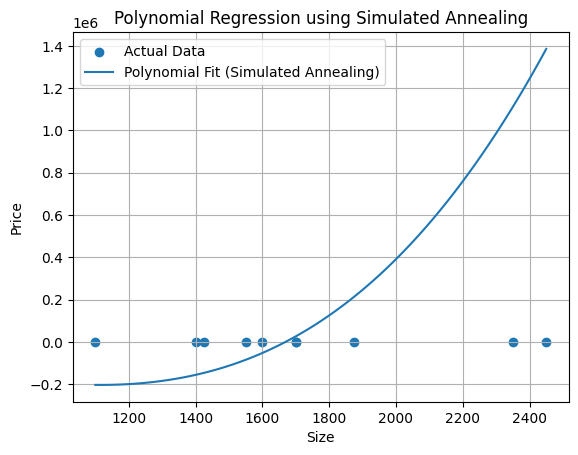

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
size = np.array([1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700])
price = np.array([245, 312, 279, 308, 199, 219, 405, 324, 319, 255])

# ==============================
# POLYNOMIAL FUNCTION
# ==============================
def polynomial(x, coeffs):
    y = 0
    for i in range(len(coeffs)):
        y += coeffs[i] * (x ** i)
    return y

# ==============================
# MSE FUNCTION
# ==============================
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# ==============================
# SIMULATED ANNEALING
# ==============================
degree = 3  # polynomial degree
coeffs = np.random.randn(degree + 1)

T = 100              # initial temperature
iterations = 1000

best_coeffs = coeffs.copy()
best_error = mse(price, polynomial(size, coeffs))

for i in range(iterations):

    # create new solution (small change)
    new_coeffs = coeffs + np.random.normal(0, 0.1, size=coeffs.shape)

    # calculate error
    y_new = polynomial(size, new_coeffs)
    error_new = mse(price, y_new)

    # acceptance condition
    if error_new < best_error or np.random.rand() < np.exp((best_error - error_new) / T):
        coeffs = new_coeffs
        best_error = error_new
        best_coeffs = new_coeffs

    # reduce temperature
    T *= 0.99

print("Best Coefficients:", best_coeffs)

# ==============================
# POLYNOMIAL PLOT
# ==============================
x_range = np.linspace(min(size), max(size), 100)
y_poly = polynomial(x_range, best_coeffs)

plt.figure()
plt.scatter(size, price, label="Actual Data")
plt.plot(x_range, y_poly, label="Polynomial Fit (Simulated Annealing)")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Polynomial Regression using Simulated Annealing")
plt.legend()
plt.grid()
plt.show()